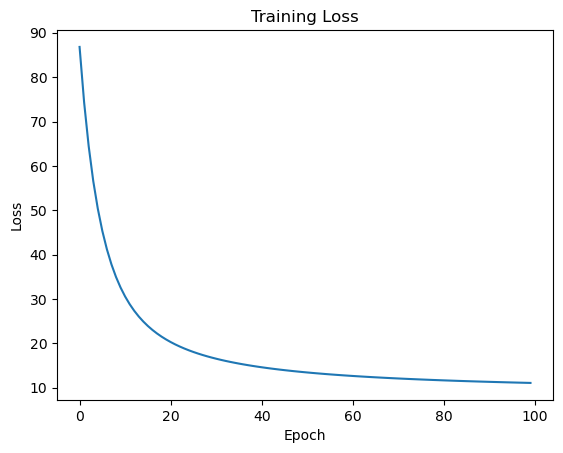

C:\Users\octopus\AppData\Local\Temp\ipykernel_9252\23601552.py:55: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true = torch.tensor([v*coef + 1.5 for v in x])


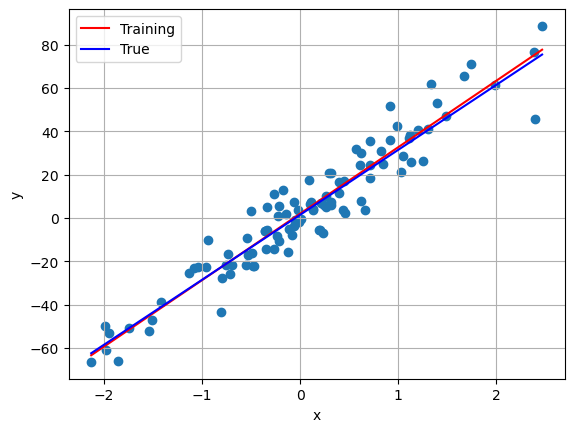

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from  torch.utils.data import TensorDataset
from  torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 生成回归数据集：100个样本，1个特征，噪声10，偏置1.5，返回真实系数
x,y,coef = make_regression(n_samples=100, n_features=1, noise=10,bias=1.5, coef=True,random_state=10)

# 将numpy数据转换为Tensor并封装成TensorDataset
dateset = TensorDataset(torch.from_numpy(x),torch.from_numpy(y))

# 创建DataLoader，每批10个样本，打乱顺序
dataloader = DataLoader(dateset,batch_size=10,shuffle=True)

# 定义线性模型：输入1维，输出1维
model = nn.Linear(1,1)

# 定义损失函数为均方误差，优化器为SGD，学习率0.01
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.01)

# 训练总轮数100，记录每轮平均损失的列表，累计损失和样本数初始化
epochs = 100
loss_list = []
total_loss = 0.
train_sample = 0.

for epoch in range(epochs):
    for x_batch,y_batch in dataloader: 
        y_pred = model(x_batch.type(torch.float32))  # 前向传播，得到预测值
        loss = loss_fn(y_pred,y_batch.reshape(-1,1).type(torch.float32))  # 计算损失
        optimizer.zero_grad()  # 清空梯度
        loss.backward()  # 反向传播，计算梯度
        optimizer.step()  # 更新模型参数
        total_loss += loss.item()  # 累加损失值
        train_sample += len(y_batch)  # 累加训练样本数
    loss_list.append(total_loss/train_sample)  # 记录本轮平均损失

# 绘制训练损失曲线
plt.plot(range(epochs),loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

plt.scatter(x,y)

# 生成用于可视化的连续x值
x = torch.linspace(x.min(), x.max(), 100)
# 计算模型预测值
y_train = torch.tensor([v*model.weight + model.bias for v in x])
# 计算真实函数值
y_true = torch.tensor([v*coef + 1.5 for v in x])

# 绘制模型预测与真实函数对比图
plt.plot(x, y_train, color='r', label='Training')
plt.plot(x, y_true, color='blue', label='True')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()